# Escore Modelling Notebook

This notebook is dedicated to fitting the Escore model. It requires building a training dataset made of *echotypes*. See the "Echotypes Extraction Notebook" for more information.

## Using *echoclasses* to fit an `EscoreModel` instance

We have aggregated samples by echotypes (since samples originate from the echotypes manual selection step), and clustered echotypes into echoclasses using a hierarchical clustering with "Ward" linkage in $\Delta \text{MVBS}$ space. By transmitting the echoclasses' to the echotypes' raw samples, we now have raw samples distributions for echoclasses. Each echoclass now contains all its echotypes raw samples. 

We now want to learn how to classify raw samples into echoclasses.

### The Escore model, concept and proposed modifications

The Escore model (Annasawmy et al., 2024) was developped for this purpose. It assumes that each echoclass distribution is Gaussian. However, the original implementation is not entirely probabilistic. It works as follows:

**Fit:** Learn each echoclass' mean ($\mu$) and covariance matrix ($\Sigma$)
**Predict:**
- Project the sample in $\Delta \text{MVBS}$ space.
- Compute the squared Mahalanobis distance ($D_M^2 = (x - \mu)^T \Sigma^{-1} (x - \mu)$) to each echoclass'.
- **Thresholds:** Closest echoclass is predicted if
  - $D_{M\text{closest}}^2(x) < E_{\text{threshold}}$
  - $D_{M\text{closest}}^2(x) / D_{M \text{2}^\text{nd}\text{closest}}^2(x) < Q_{\text{threshold}}$

The major difference in prediction between this approach and a series of Gaussian models (one for each class) is the transformation on the distance metric. Indeed, the Gaussian PDF in a $p$-dimensional space is given by:

$$
\frac{1}{\sqrt{(2 \pi)^p |\Sigma|}} \exp(- D_M / 2)
$$

The square transformation in the distance will then affect the prediction boundaries in $\Delta \text{MVBS}$ space.

One could also argue that since we only learn mean and covariance we actually learn Gaussian distributions. Dropping out of the Gaussian framework brings little benefits (the impact of the shift in prediction boundaries - see above - is not obviously beneficial) but comes at quite a big cost: clarity; interpretability; goodness of fit metrics; inability to reuse standard libraries.

In [9]:
import pandas as pd

DATA_PATH = "../private/echotypes_classified.parquet"
CHANNEL_COLS = ["channel_0_Sv", "channel_1_Sv", "channel_2_Sv"]


dataset = pd.read_parquet(DATA_PATH)
X, y = dataset[CHANNEL_COLS], dataset["echoclass_id"]
echotype_ids = dataset["echotype_id"]

### Custom Escore estimator: collection of Gaussian models

In [10]:
from sklearn.pipeline import Pipeline
from escore.pipelines.transformers import SvDifferenceExtractor
from escore.pipelines.classifier import EscoreClassifier

escore = Pipeline([
    ("features", SvDifferenceExtractor(0)),
    ("clf", EscoreClassifier())
])
escore

,steps,"[('features', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,ref_channel_idx,0
,e_thresh,0.01
,q_thresh,0.5


In [11]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import make_scorer
from escore.evaluation.metrics import coverage2, classified_accuracy, combined_score2, rejection_safe_accuracy

# TODO : Create more scoring metrics (maybe treat rejected as classes that are always wrong)
scoring = {
    "accuracy": make_scorer(rejection_safe_accuracy, unsure_sample_weight=0.5),
    "coverage": make_scorer(coverage2),
    "classified_accuracy": make_scorer(classified_accuracy),
    "combined": make_scorer(combined_score2, alpha=0.5, unsure_sample_weight=0.5),
}

escore_gridsearch = GridSearchCV(
    escore,
    param_grid={
        "clf__e_thresh": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "clf__q_thresh": [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.]
    },
    scoring=scoring,
    refit="accuracy",  # which metric to use for selecting best params
    cv=GroupKFold(n_splits=5),
)

In [12]:
escore_gridsearch.fit(X, y, groups=echotype_ids)
cv_results = pd.DataFrame(escore_gridsearch.cv_results_)
cv_results = cv_results.sort_values("rank_test_combined")

In [13]:
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__e_thresh,param_clf__q_thresh,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,...,std_test_classified_accuracy,rank_test_classified_accuracy,split0_test_combined,split1_test_combined,split2_test_combined,split3_test_combined,split4_test_combined,mean_test_combined,std_test_combined,rank_test_combined
2,0.001420,0.000094,0.001397,0.000100,0.00001,0.70,"{'clf__e_thresh': 1e-05, 'clf__q_thresh': 0.7}",0.813497,0.860487,0.865466,...,0.096996,24,0.906503,0.926921,0.931217,0.954055,0.792711,0.902281,0.056830,1
1,0.001499,0.000092,0.001371,0.000054,0.00001,0.60,"{'clf__e_thresh': 1e-05, 'clf__q_thresh': 0.6}",0.812761,0.858576,0.862541,...,0.097555,21,0.906135,0.925966,0.929754,0.953275,0.795544,0.902135,0.055360,2
3,0.001397,0.000032,0.001403,0.000026,0.00001,0.80,"{'clf__e_thresh': 1e-05, 'clf__q_thresh': 0.8}",0.812638,0.862518,0.865934,...,0.096294,28,0.906074,0.927937,0.931451,0.954595,0.790274,0.902066,0.057975,3
4,0.001390,0.000043,0.001377,0.000107,0.00001,0.90,"{'clf__e_thresh': 1e-05, 'clf__q_thresh': 0.9}",0.811411,0.864548,0.867103,...,0.095609,29,0.905460,0.928952,0.932035,0.954295,0.788166,0.901782,0.058878,4
5,0.001393,0.000051,0.001357,0.000090,0.00001,0.95,"{'clf__e_thresh': 1e-05, 'clf__q_thresh': 0.95}",0.810429,0.864548,0.866869,...,0.095128,30,0.904969,0.928952,0.931919,0.954535,0.787507,0.901576,0.059157,5


In [14]:
# Print best results
best_results = cv_results.iloc[0]
print("Best model results:")
print(f"* Accuracy (incl. rejected): {best_results['mean_test_accuracy']:.3f} ± {best_results['std_test_accuracy']:.3f}")
print(f"* Coverage (not rejected): {best_results['mean_test_coverage']:.3f} ± {best_results['std_test_coverage']:.3f}")
print(f"* Accuracy (on classified): {best_results['mean_test_classified_accuracy']:.3f} ± {best_results['std_test_classified_accuracy']:.3f}")
print(f"* Combined: {best_results['mean_test_combined']:.3f} ± {best_results['std_test_combined']:.3f}")

print(f"Best model params: {escore_gridsearch.best_params_}")

Best model results:
* Accuracy (incl. rejected): 0.820 ± 0.089
* Coverage (not rejected): 0.985 ± 0.025
* Accuracy (on classified): 0.841 ± 0.097
* Combined: 0.902 ± 0.057
Best model params: {'clf__e_thresh': 0.01, 'clf__q_thresh': 0.95}


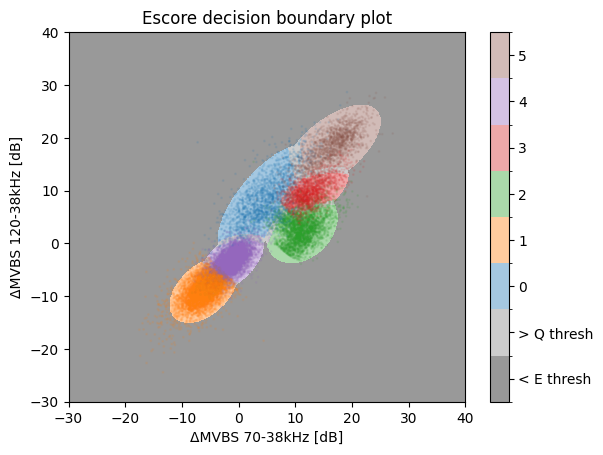

In [15]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from escore.pipelines.boundaries import escore_boundary_plot

# Fit a model with 
model = escore.set_params(clf__e_thresh=0.001, clf__q_thresh=0.5)
model.fit(X, y)

fig, ax = plt.subplots()

# Boundary plot
escore_boundary_plot(model["clf"], ax, grid_resolution=1000, xrange=(-30, 40), yrange=(-30, 40), alpha=0.4) # type: ignore

# Add scatter of samples
# Preprocess data (project in ΔMVBS space)
X_preproc = model["features"].transform(X) # type: ignore

# Scatterplot
classes_colors = list(plt.get_cmap("tab10").colors[:len(model.classes_)])
cmap_classes = ListedColormap(classes_colors)
ax.scatter(X_preproc[:, 0], X_preproc[:, 1], s=1, c=y.astype(int), cmap=cmap_classes, alpha=1e-1)

# Format with real axes values
ax.set_xlim(-30, 40)
ax.set_xlabel("ΔMVBS 70-38kHz [dB]")
ax.set_ylabel("ΔMVBS 120-38kHz [dB]");

In [16]:
import joblib

joblib.dump(model, "../private/escore_model.pkl")

['../private/escore_model.pkl']

## Predicting on acoustic dataset

Now that we have selected an escore model, we can use it to predict on our acoustic dataset. Thanks to `xarray`'s `apply_ufunc` function, we can predict very efficiently at a minimal coding cost.

The first step is to load the dataset, as well as the model we want to use.

In [17]:
import xarray as xr
import joblib

ds_MVBS: xr.Dataset = xr.open_dataset("/Users/gaspardringuenet/Data/tapioca/Abracos_A2/Abracos_A2_10s1m.zarr")
model = joblib.load("../private/escore_model.pkl")

To predict, we must first reshape the data so it can be consumed by the model. `sklearn` estimators ingest data in shape (n_samples, n_features). 

In our model, n_features is related to the frequency channels used in training data. **Beware:** `SvDifferenceExtractor` defined which of the features is subtracted to the others when computing $\Delta \text{MVBS}$. *Make sure channels order is coherent with training data* for correct predictions.

Xarray provides the necessary utilities for stacking / unstacking dimensions. We will stack the `ping_time` and `depth` dimension as a single `sample` dimension.

In [18]:
%%time
# Get data & select features matching the model's
da_Sv: xr.DataArray = ds_MVBS.Sv.isel(channel=[0, 1, 2])

# Stack (ping_time, depth) into a flat sample dimension -> (n_samples, channel)
da_stacked = da_Sv.stack(sample=("ping_time", "depth")).transpose("sample", "channel")
da_stacked = da_stacked.dropna("sample", how="any") # drop NAs

print(f"Stacked DataArray shape: {da_stacked.shape} (n_samples, n_features)")

Stacked DataArray shape: (38041363, 3) (n_samples, n_features)
CPU times: user 4.34 s, sys: 2.17 s, total: 6.51 s
Wall time: 6.59 s


**Note:** This step is quite long as stacking loads the data into memory despite lazy-loading the dataset at first.

Now that the data is in correct shape, we can apply our fitted model's `.predict` method to each sample using `xarray.apply_unfunc`.

In [19]:
%%time
import warnings

# Predict on flat DataArray
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning)
    da_preds_stacked = xr.apply_ufunc(
        model.predict,
        da_stacked,
        input_core_dims=[['channel']],
        output_core_dims=[[]],
        output_dtypes=[int]
    )

# Reshape to (ping_time, depth)
da_preds: xr.DataArray = da_preds_stacked.unstack("sample")
da_preds = da_preds.reindex_like(da_Sv)  # Reindex to original grid, fills missing with NaN
da_preds.name = "Echoclass"

CPU times: user 30.7 s, sys: 15.7 s, total: 46.4 s
Wall time: 13.9 s


In [20]:
# Save
da_preds.to_zarr("../private/echoclasses.zarr", mode="w")

### Visualization

A quick visualization of the predicted classes in relation with acoustic data can provide information on the classification. hvPlot's ability to synchronize plots sharing the same coordinates allow easy inspection of the classification.

In [21]:
import xarray as xr

da_preds = xr.open_dataarray("../private/echoclasses.zarr")
ds_MVBS: xr.Dataset = xr.open_dataset("/Users/gaspardringuenet/Data/tapioca/Abracos_A2/Abracos_A2_10s1m.zarr")

# Select only one day for faster computation & render (comment for full data)
ds_MVBS = ds_MVBS.sel(ping_time=slice('2017-04-09', '2017-04-12'))
da_preds = da_preds.sel(ping_time=slice('2017-04-09', '2017-04-12'))

# Load
da_Sv: xr.DataArray = ds_MVBS.Sv.load()
_ = da_preds.load()

In [22]:
import holoviews as hv
import hvplot.xarray
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

hv.output(widget_location='bottom')

# User parameters
n_classes = 6
vmin, vmax = -90, -50
rgb_channels = [0, 1, 2]

# Compute RGB echogram
da_raw: xr.DataArray = da_Sv.isel(channel=rgb_channels)
da_raw = da_raw.transpose('ping_time', 'depth', 'channel')
da = (da_raw - vmin) / (vmax - vmin)
da = da.clip(0, 1)   
da = da.fillna(0)
da = xr.where(da_raw.isel(channel=0).isnull(), np.nan, da) # channel 0 as ref for NAs
da_RGB = da_raw.copy()
da_RGB.data = da.data
da_RGB.name = "MVBS_RGB_Composite"

# Prepare classification cmap
classes_colors = list(plt.get_cmap("tab10").colors[:n_classes])
cmap = ListedColormap(["black", "grey"] + classes_colors)

# Echogram plot arguments
plot_kwrgs = dict(x="ping_time", y="depth", flip_yaxis=True, rasterize=True, width=500)

# Build plots
p_classif = da_preds.hvplot.quadmesh(cmap=cmap, clim=(-2, 5), aggregator='first', **plot_kwrgs)
p_echog = da_Sv.hvplot.quadmesh(cmap="viridis", clim=(vmin, vmax), **plot_kwrgs)
p_rgb_echog = da_RGB.transpose("depth", "ping_time", "channel").hvplot.rgb(bands='channel', **plot_kwrgs)

In [24]:
p_rgb_echog + p_classif

BokehModel(combine_events=True, render_bundle={'docs_json': {'68bfea4d-58aa-438a-9e6e-8f982ef3b385': {'version…